<a href="https://colab.research.google.com/github/kartik0920/Hands-on-Machine-learning/blob/Main/chapter_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Classification Models


##Fetching data from Internet

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
HOME_PATH="/content/drive/MyDrive/Jan 2k25/chapter 3"

data_url=os.path.join(HOME_PATH,"mnist_784.csv")

In [3]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

In [4]:
mnist=pd.read_csv(data_url)
x=mnist.drop("class",axis=1)
y=mnist["class"]

In [5]:
some_digit=x.iloc[12]
some_digit_img=some_digit.values.reshape(28,28)

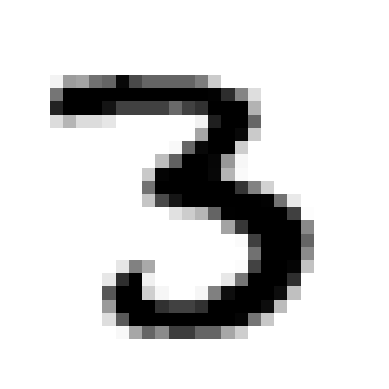

In [6]:
plt.imshow(some_digit_img,cmap="binary")
plt.axis('off')
plt.show()

In [7]:
y=y.astype(np.int8)

##Binary CLaissifer

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1,random_state=42)

In [12]:
y_train_3= (y_train == 3) #check for 3
y_test_3= (y_test == 3)

Stochastic Gradient Descent model

In [13]:
from sklearn.linear_model import SGDClassifier
sgd_clf=SGDClassifier(random_state=42)
sgd_clf.fit(x_train,y_train_3)

SGDClassifier(random_state=42)

In [14]:
sgd_clf.predict([some_digit])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([ True])

In [15]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf,x_train,y_train_3,cv=3,scoring="accuracy")

array([0.95961905, 0.96961905, 0.96652381])

Here we prefer confusion matrix  because accuracy is not good

In [16]:
from sklearn.model_selection import cross_val_predict

In [17]:
y_pred=cross_val_predict(sgd_clf,x_train,y_train_3,cv=3)

In [18]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train_3,y_pred)

array([[56043,   576],
       [ 1613,  4768]])

In [19]:
from sklearn.metrics import precision_score,recall_score
from sklearn.metrics import f1_score


In [20]:
precision_score(y_train_3,y_pred) #it shows how many time correct of 100

0.8922155688622755

In [21]:
recall_score(y_train_3,y_pred) #it shows how many were detected

0.7472183043410123

In [22]:
f1_score(y_train_3,y_pred)

0.8133049040511727

##Precision recall curve

In [23]:
from sklearn.metrics import precision_recall_curve

In [24]:
y_scores=cross_val_predict(sgd_clf,x_train,y_train_3,cv=3)

In [25]:
precision,recall,threshold=precision_recall_curve(y_train_3,y_scores)

In [26]:
def plot_precision_recall_vs_thresholf(precision,recall,threshold):
  plt.plot(threshold,precision[:-1],'--g',label="precision")
  plt.plot(threshold,recall[:-1],'-b',label="recall")
  [...]

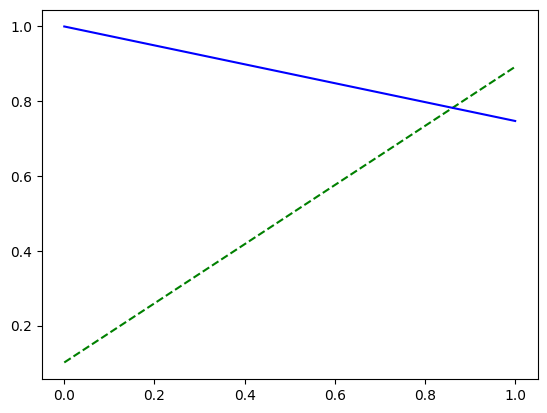

In [27]:
plot_precision_recall_vs_thresholf(precision,recall,threshold)
plt.show()

##Roc curve

In [28]:
from sklearn.metrics import roc_curve

In [29]:
fpr,tpr,threshold=roc_curve(y_train_3,y_scores)

In [30]:
def roc_plot(fpr,tpr,label=None):
  plt.plot(fpr,tpr,linewidth=2,label=label)
  plt.plot([0,1],[0,1],'k--')
  [...]

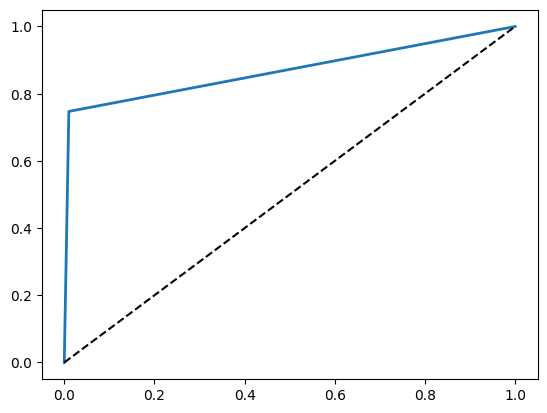

In [31]:
roc_plot(fpr,tpr)
plt.show()

##Multiclass classifier


In [33]:
from sklearn.svm import SVC

In [34]:
svc_clf=SVC()
svc_clf.fit(x_train,y_train)

SVC()

In [42]:
import joblib

joblib.dump(svc_clf,"svc_clf.pkl")

['svc_clf.pkl']

In [37]:
prediction_svc_clf=svc_clf.predict(x_test)


In [41]:
x_test.shape

(7000, 784)

In [38]:
confusion_matrix(prediction_svc_clf,y_test)

array([[679,   0,   1,   0,   1,   1,   2,   0,   1,   3],
       [  0, 791,   1,   2,   0,   0,   0,   4,   3,   5],
       [  1,   3, 662,   8,   1,   0,   0,   8,   3,   1],
       [  0,   2,   0, 729,   0,   9,   0,   0,   9,   5],
       [  0,   0,   2,   2, 598,   0,   3,   4,   1,   4],
       [  0,   0,   0,   8,   0, 638,   3,   0,   4,   1],
       [  0,   0,   3,   0,   2,   6, 668,   0,   3,   0],
       [  0,   3,   2,   3,   1,   1,   0, 702,   4,   4],
       [  2,   0,   3,   4,   1,   3,   1,   0, 663,   2],
       [  1,   1,   0,   4,   7,   0,   0,   6,   2, 695]])

In [44]:
from sklearn.preprocessing import StandardScaler
std_scaler=StandardScaler()

x_train_scaled=std_scaler.fit_transform(x_train.astype(np.float64))

In [46]:
cross_val_score(sgd_clf,x_train ,y_train,cv=3,scoring="accuracy")

array([0.87747619, 0.88833333, 0.87095238])

In [45]:
cross_val_score(sgd_clf,x_train_scaled,y_train,cv=3,scoring="accuracy")

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([0.909     , 0.90604762, 0.89304762])